In [ ]:
# python3 notebook
# simple script reading in the updated HI observations of Local Group dwarf galaxies

In [1]:
import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
#import gala.potential as gp
#import gala.dynamics as gd
#from gala.units import galactic, solarsystem, dimensionless
from astropy.constants import G
from astropy.cosmology import Planck18_arXiv_v2 as cosmo
from astropy import constants as const
from matplotlib.ticker import AutoMinorLocator

# import additional obsn packages
from astropy.coordinates import SkyCoord
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
from astropy import constants as const

import astropy.coordinates as coord
from astropy.coordinates import spherical_to_cartesian
from astropy.coordinates import SkyCoord
from astropy.coordinates import match_coordinates_3d
from astropy.coordinates import search_around_3d

from scipy.integrate import quad

plt.rc('font', size=16)

In [2]:
#data_dir= '../paper_data/'

# local group dwarf galaxy data from Mary's 2021 paper
# all dwarf galaxies within 2 Mpc of the Milky Way, stellar data from McConnachie, HI gas data newly compiled

data_P21_dir = data_dir + 'putman21_lg_dwarfs/' # read in the data files from your local directory

# the relevant table for LG dwarf orbits is table 3
putman_dwarf_orbit_tbl = Table.read(data_P21_dir + 'table3.dat',
                                    readme=data_P21_dir + 'ReadMe',
                                    format='ascii')

# table 1: HI masses (including upper limits etc) and coordinates 
putman_dwarf_hi_coord_tbl = Table.read(data_P21_dir + 'table1.dat',
                                       readme=data_P21_dir + 'ReadMe',
                                       format='ascii')

# table 2: 
putman_dwarf_stellar_tbl = Table.read(data_P21_dir + 'table2.dat',
                                       readme=data_P21_dir + 'ReadMe',
                                       format='ascii') 

In [5]:
# table 1 quick view: HI mass, coordinates and more
# the column l_MHI states whether it's HI mass or upper limit (< for upper limits)
# the upper limit dwarfs are typically considered gasless/quenched LG dwarfs

putman_dwarf_hi_coord_tbl.show_in_notebook()

idx,Name,f_Name,RAh,RAm,RAs,DE-,DEd,DEm,DEs,Vel,Dist,e_Dist,E_Dist,Data,Method,sigHI,l_MHI,MHI,e_MHI,E_MHI,rPos,r_Vel,r_Dist
,,,h,min,s,,deg,arcmin,arcsec,km / s,kpc,kpc,kpc,,,mK,,Msun,Msun,Msun,,,
0,Draco II,--,15,52,48,+,64,33,55,-343,22,0.4,--,HI4PI,Unres.,17.0,<,57,2,--,5,6,6
1,Segue 1,--,10,7,4,+,16,4,55,209,23,2.0,--,GALFA1,Res.,17.0,<,47,8,--,5,6,6
2,DESJ0225+0304,--,2,25,42,+,3,4,10,--,24,1.0,--,GALFA2,Unres. No V,97.0,<,71,4,--,7,--,7
3,Tucana III,--,23,56,36,-,59,36,0,-102,25,2.0,--,HI4PI,Unres.,20.0,<,90,14,--,5,6,6
4,Sagittarius dSph,8,18,55,20,-,30,32,43,139,27,1.0,--,HI4PI,Unres.,25.0,<,126,12,--,5,6,6
5,Hydrus I,--,2,29,33,-,79,18,32,80,28,1.0,--,HI4PI,Unres.,23.0,<,125,5,--,9,6,6
6,Carina III,--,7,38,31,-,57,53,59,285,28,1.0,--,HI4PI,Unres.,18.0,<,101,4,--,10,6,6
7,Triangulum II,--,2,13,17,+,36,10,42,-382,28,2.0,--,HI4PI,Unres.,19.0,<,107,12,--,5,6,6
8,Cetus II,--,1,17,53,-,17,25,12,--,30,3.0,--,HI4PI,Unres. No V,20.0,<,127,26,--,5,--,6


In [6]:
# stellar mass (in terms of V band luminosity, consistent with McConnachie12 updated)
# distances to the host, see DMW and DM31, whichever is closer means it's more associated with that host
# DLG is distance to some modeled local group boundary

putman_dwarf_stellar_tbl.show_in_notebook()

idx,Name,Lv,rh,l_sigma,sigma,sigma2,DMW,DM31,DLG,DLGh,DLGl,r_Lv,r_rh,r_sigma
,,Lsun,pc,,km / s,km / s,kpc,kpc,kpc,kpc,kpc,,,
0,Draco II,180.0,19,--,2.9,--,24,771,-210,15,-15,6,6,7
1,Segue 1,280.0,24,--,3.7,--,28,788,-197,18,-17,6,6,6
2,DESJ0225+0304,240.0,19,--,--,--,29,762,-214,14,-15,6,6,--
3,Tucana III,340.0,37,<,1.2,--,23,784,-203,18,-17,6,6,6
4,Sagittarius dSph,21000000.0,2662,--,11.4,--,19,787,-206,19,-17,6,6,6
5,Hydrus I,6500.0,53,--,2.7,--,26,794,-198,20,-17,6,6,6
6,Carina III,780.0,30,--,5.6,--,29,797,-195,20,-18,6,6,6
7,Triangulum II,370.0,16,<,3.4,--,35,752,-222,12,-14,6,6,6
8,Cetus II,86.0,17,--,--,--,32,764,-208,13,-14,6,6,--


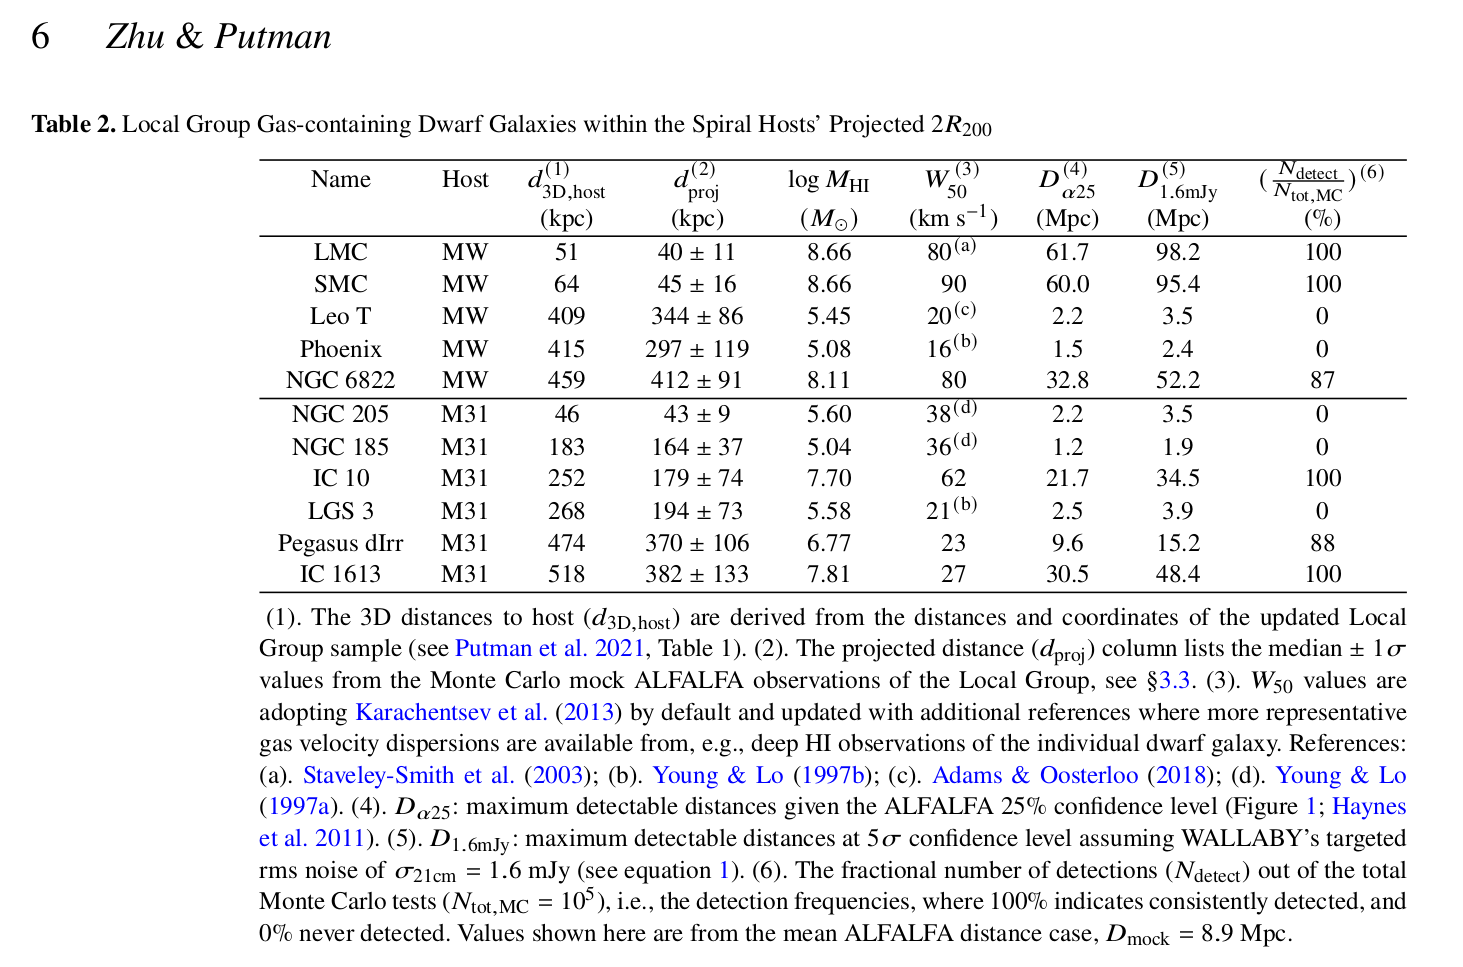

In [7]:
# there are not many gaseous sats within MW or M31's Rvir (2Rvir) radii
# the few ones with gas within their hosts' projected 2R200 (in our mock Local Group observations) are attached 

from IPython.display import Image
Image(filename=data_P21_dir + 'lg_2rvir_gaseous_sats.png') 